<a href="https://colab.research.google.com/github/WVF-1/Movie-Performance-Analytics/blob/main/Financial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Movie Performance Analytics — Notebook 2
## Financial Performance Analysis

**Series:** May Newsletter — Movie Intelligence  
**Prerequisite:** Run Notebook 1 first to generate `movies_clean.parquet`

### Questions we answer
1. **Which genres are most profitable?** (by median ROI and total revenue)
2. **Does a bigger budget guarantee success?** (budget tier vs ROI)
3. **When should you release a film?** (monthly profitability patterns)
4. **What are the biggest hits and biggest flops?** (top/bottom film rankings)

All analysis uses the *analysis-ready* subset (~4,800 films with both budget and revenue recorded).


## 0 · Setup

In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

df = pd.read_parquet("movies_clean.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)


Loaded: 5,128 rows × 23 columns


,id,imdb_id,title,release_date,release_year,release_month,month_name,decade,budget,revenue,...,budget_tier,vote_average,vote_count,popularity,runtime,primary_genre,genre_list,genre_count,original_language,production_countries
0,862,tt0114709,Toy Story,1995-10-30,1995.0,10.0,Oct,1990,30000000.0,373554033.0,...,Mid ($15M–$60M),7.7,5415.0,21.946943,81.0,Animation,"[Animation, Comedy, Family]",3,en,"[{'iso_3166_1': 'US', 'name': 'United States o..."
1,8844,tt0113497,Jumanji,1995-12-15,1995.0,12.0,Dec,1990,65000000.0,262797249.0,...,Blockbuster (>$60M),6.9,2413.0,17.015539,104.0,Adventure,"[Adventure, Fantasy, Family]",3,en,"[{'iso_3166_1': 'US', 'name': 'United States o..."
2,31357,tt0114885,Waiting to Exhale,1995-12-22,1995.0,12.0,Dec,1990,16000000.0,81452156.0,...,Mid ($15M–$60M),6.1,34.0,3.859495,127.0,Comedy,"[Comedy, Drama, Romance]",3,en,"[{'iso_3166_1': 'US', 'name': 'United States o..."


## 1 · Genre Profitability — ROI & Revenue

In [ ]:
# Only use genres with at least 30 qualifying films for statistical credibility
genre_stats = (
    df.groupby("primary_genre")
    .agg(
        film_count   = ("title",        "count"),
        median_ROI   = ("ROI",          "median"),
        mean_ROI     = ("ROI",          "mean"),
        median_profit= ("profit",       lambda x: x.median() / 1e6),
        total_revenue= ("revenue",      lambda x: x.sum()    / 1e9),
        avg_rating   = ("vote_average", "mean"),
    )
    .query("film_count >= 30")
    .sort_values("median_ROI", ascending=False)
    .reset_index()
)

print(f"Genres with ≥30 films: {len(genre_stats)}")
genre_stats.round(2)


Genres with ≥30 films: 17


,primary_genre,film_count,median_ROI,mean_ROI,median_profit,total_revenue,avg_rating
0,Documentary,40,2.66,152.44,3.09,0.75,6.92
1,Horror,321,2.02,3180.93,18.50,16.65,5.86
2,Family,53,1.83,5.43,51.42,13.23,6.26
3,Science Fiction,101,1.59,4.63,34.95,17.32,6.30
4,Animation,144,1.48,6.33,81.49,35.16,6.47
5,Western,31,1.37,5.92,5.00,1.38,6.91
6,Adventure,404,1.33,2525.18,49.55,82.65,6.39
7,Comedy,1009,1.24,32.03,13.89,68.08,6.13
8,Fantasy,137,1.15,3.44,34.66,18.58,6.23
9,Romance,106,1.04,3.12,15.04,8.46,6.40


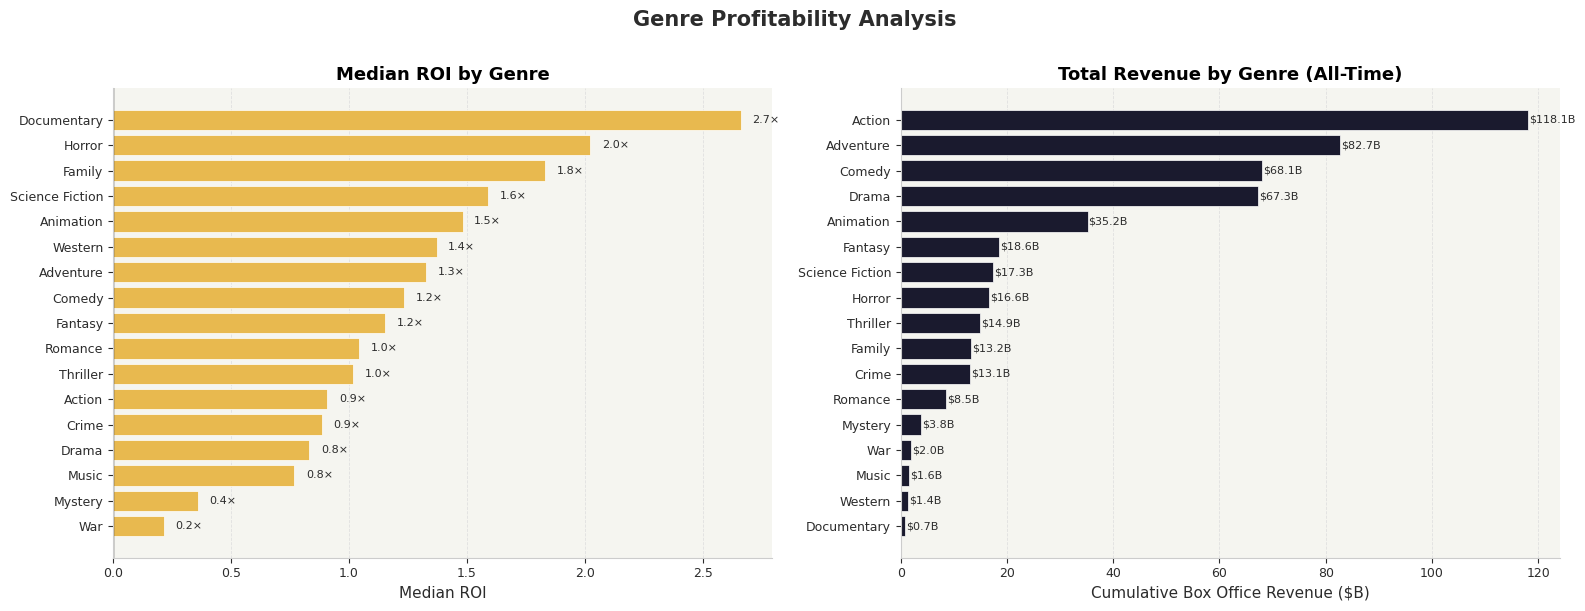

Saved: nb2_genre_profitability.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Genre Profitability Analysis", fontsize=15, fontweight="bold",
             color=DARK_TEXT, y=1.01)

# ── Left: Median ROI by genre ──────────────────────────────────────
ax = axes[0]
g  = genre_stats.sort_values("median_ROI", ascending=True)

colors = [GOLD if x > 0 else CRIMSON for x in g["median_ROI"]]
bars = ax.barh(g["primary_genre"], g["median_ROI"], color=colors, edgecolor="white", linewidth=0.5)

ax.axvline(0, color=DARK_TEXT, linewidth=1)
ax.set_xlabel("Median ROI")
ax.set_title("Median ROI by Genre")
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True)
ax.set_axisbelow(True)

# value labels
for bar, val in zip(bars, g["median_ROI"]):
    offset = 0.05 if val >= 0 else -0.05
    ha     = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}×", va="center", ha=ha, fontsize=8, color=DARK_TEXT)

# ── Right: Total box office revenue by genre ───────────────────────
ax = axes[1]
g2 = genre_stats.sort_values("total_revenue", ascending=True)

ax.barh(g2["primary_genre"], g2["total_revenue"],
        color=MIDNIGHT, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Cumulative Box Office Revenue ($B)")
ax.set_title("Total Revenue by Genre (All-Time)")
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True)
ax.set_axisbelow(True)

for p in ax.patches:
    ax.text(p.get_width() + 0.2, p.get_y() + p.get_height()/2,
            f"${p.get_width():.1f}B", va="center", fontsize=8, color=DARK_TEXT)

plt.tight_layout()
plt.savefig("nb2_genre_profitability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb2_genre_profitability.png")


## 2 · Budget vs Revenue — Does Spending More Pay Off?

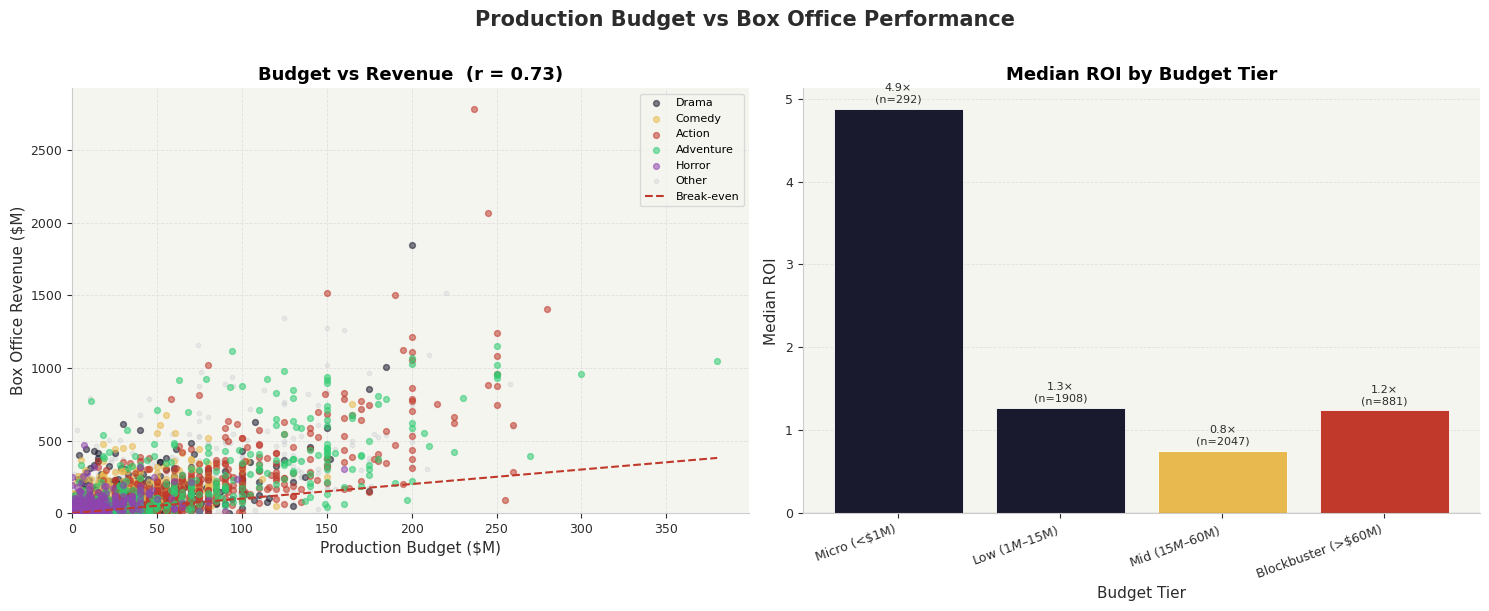

Saved: nb2_budget_vs_revenue.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Production Budget vs Box Office Performance",
             fontsize=15, fontweight="bold", color=DARK_TEXT, y=1.01)

# ── Left: Budget vs Revenue scatter ────────────────────────────────
ax = axes[0]

# Color by primary genre — highlight top 5 genres, rest grey
top_genres = df["primary_genre"].value_counts().head(5).index.tolist()
GENRE_COLORS = {g: c for g, c in zip(top_genres,
    [MIDNIGHT, GOLD, CRIMSON, "#2ecc71", "#8e44ad"])}

for genre in top_genres:
    subset = df[df["primary_genre"] == genre]
    ax.scatter(subset["budget"]/1e6, subset["revenue"]/1e6,
               color=GENRE_COLORS[genre], alpha=0.55, s=18, label=genre, zorder=3)

others = df[~df["primary_genre"].isin(top_genres)]
ax.scatter(others["budget"]/1e6, others["revenue"]/1e6,
           color=SILVER, alpha=0.25, s=10, label="Other", zorder=2)

# Break-even line
max_b = df["budget"].max() / 1e6
ax.plot([0, max_b], [0, max_b], color=CRIMSON, linestyle="--", linewidth=1.5,
        label="Break-even", zorder=4)

r, p = pearsonr(df["budget"].dropna(), df.loc[df["budget"].notna(), "revenue"])
ax.set_xlabel("Production Budget ($M)")
ax.set_ylabel("Box Office Revenue ($M)")
ax.set_title(f"Budget vs Revenue  (r = {r:.2f})")
ax.legend(fontsize=8, framealpha=0.7)
style_spines(ax)
ax.grid(True)
ax.set_axisbelow(True)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# ── Right: Median ROI by budget tier ───────────────────────────────
ax = axes[1]
TIER_ORDER = ["Micro (<$1M)", "Low ($1M–$15M)", "Mid ($15M–$60M)", "Blockbuster (>$60M)"]
tier_roi   = (df.groupby("budget_tier")["ROI"]
               .agg(["median","count"])
               .reindex(TIER_ORDER)
               .dropna())

bars = ax.bar(tier_roi.index, tier_roi["median"],
              color=[MIDNIGHT, MIDNIGHT, GOLD, CRIMSON], edgecolor="white", linewidth=0.6)
ax.axhline(0, color=DARK_TEXT, linewidth=0.8)
ax.set_xlabel("Budget Tier")
ax.set_ylabel("Median ROI")
ax.set_title("Median ROI by Budget Tier")
ax.set_xticklabels(tier_roi.index, rotation=20, ha="right")
style_spines(ax)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

for bar, (_, row) in zip(bars, tier_roi.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{row['median']:.1f}×\n(n={int(row['count'])})",
            ha="center", va="bottom", fontsize=8, color=DARK_TEXT)

plt.tight_layout()
plt.savefig("nb2_budget_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb2_budget_vs_revenue.png")


## 3 · Monthly Release Patterns

In [ ]:
monthly = (
    df.groupby("release_month")
    .agg(
        film_count   = ("title",        "count"),
        median_ROI   = ("ROI",          "median"),
        median_profit= ("profit",       lambda x: x.median() / 1e6),
        total_revenue= ("revenue",      lambda x: x.sum()    / 1e6),
    )
    .reset_index()
)

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["month_name"] = [MONTH_NAMES[int(m)-1] for m in monthly["release_month"]]

print("Monthly statistics:")
monthly[["month_name","film_count","median_ROI","median_profit","total_revenue"]].round(2)

Monthly statistics:


,month_name,film_count,median_ROI,median_profit,total_revenue
0,Jan,324,0.94,6.08,14644.26
1,Feb,343,0.96,10.31,24683.98
2,Mar,386,1.00,14.05,34999.84
3,Apr,384,0.86,9.50,33010.16
4,May,393,1.32,15.05,55918.99
5,Jun,445,1.80,29.20,70406.80
6,Jul,414,1.51,29.38,50390.02
7,Aug,445,0.94,10.50,27324.53
8,Sep,588,0.39,2.73,27585.05
9,Oct,473,0.94,8.90,31920.27


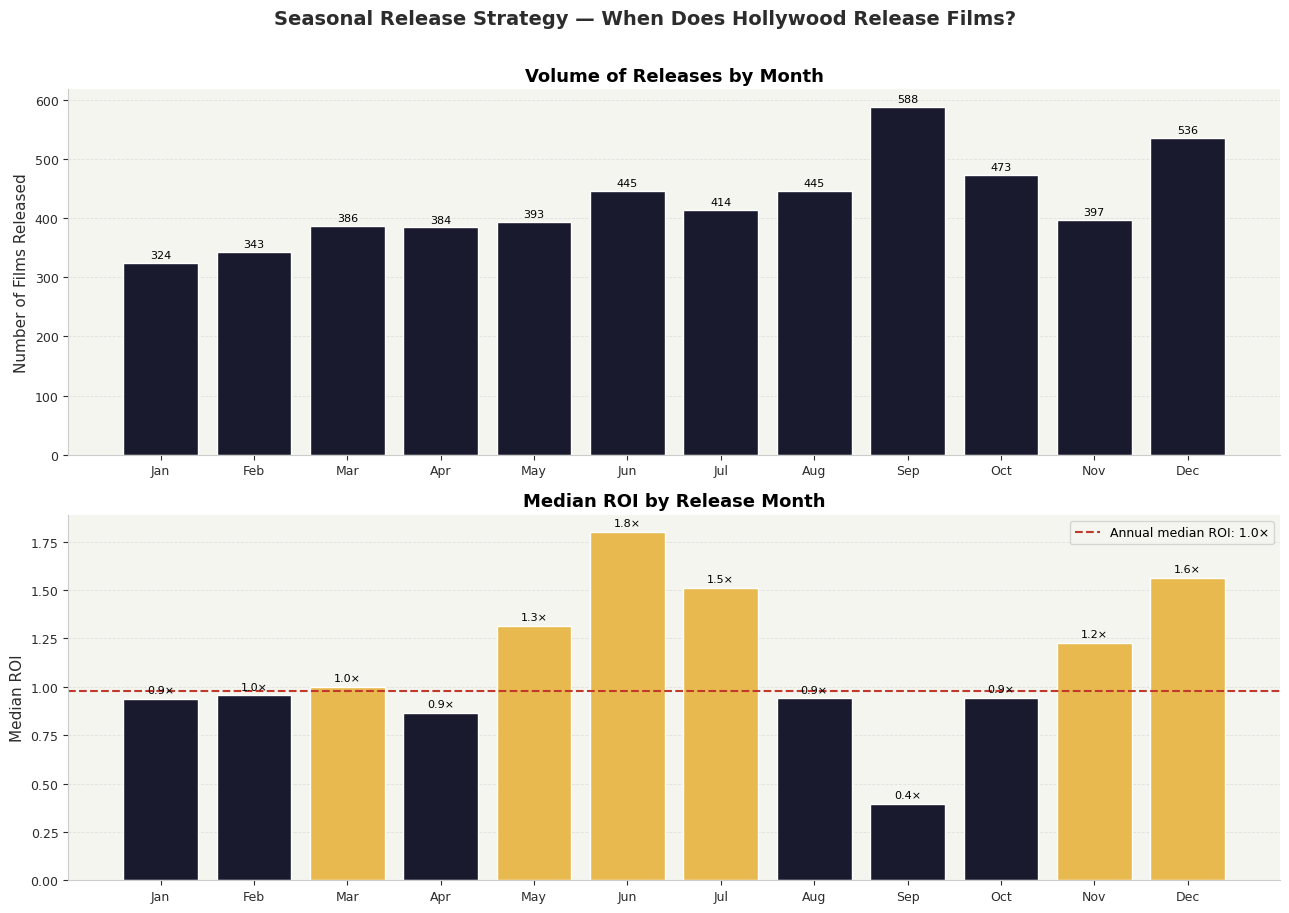

Saved: nb2_monthly_patterns.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle("Seasonal Release Strategy — When Does Hollywood Release Films?",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# ── Top: Number of releases per month ──────────────────────────────
ax = axes[0]
ax.bar(monthly["month_name"], monthly["film_count"], color=MIDNIGHT, edgecolor="white")
ax.set_ylabel("Number of Films Released")
ax.set_title("Volume of Releases by Month")
style_spines(ax)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
            int(p.get_height()), ha="center", va="bottom", fontsize=8)

# ── Bottom: Median ROI per month ────────────────────────────────────
ax = axes[1]
colors = [GOLD if r > monthly["median_ROI"].median() else MIDNIGHT
          for r in monthly["median_ROI"]]
ax.bar(monthly["month_name"], monthly["median_ROI"], color=colors, edgecolor="white")
ax.axhline(monthly["median_ROI"].median(), color=CRIMSON, linestyle="--",
           linewidth=1.5, label=f"Annual median ROI: {monthly['median_ROI'].median():.1f}×")
ax.set_ylabel("Median ROI")
ax.set_title("Median ROI by Release Month")
ax.legend()
style_spines(ax)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

for p, roi in zip(ax.patches, monthly["median_ROI"]):
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.02,
            f"{roi:.1f}×", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("nb2_monthly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb2_monthly_patterns.png")


## 4 · Top & Bottom Performers

In [ ]:
# Require a meaningful-sized film (budget > $5M) to avoid micro-budget quirks
df_ranked = df[df["budget"] > 5e6].copy()

top10_roi   = df_ranked.nlargest(10,  "ROI")[["title","release_year","budget","revenue","ROI","primary_genre"]]
bottom10    = df_ranked.nsmallest(10, "ROI")[["title","release_year","budget","revenue","ROI","primary_genre"]]
top10_profit= df_ranked.nlargest(10, "profit")[["title","release_year","budget","revenue","profit","primary_genre"]]

print("=== TOP 10 by ROI ===")
print(top10_roi.to_string(index=False))
print()
print("=== BOTTOM 10 by ROI (biggest flops) ===")
print(bottom10.to_string(index=False))
print()
print("=== TOP 10 by ABSOLUTE PROFIT ===")
top10_profit["profit_M"] = top10_profit["profit"] / 1e6
print(top10_profit[["title","release_year","budget","profit_M","primary_genre"]].to_string(index=False))


=== TOP 10 by ROI ===
                      title  release_year     budget     revenue       ROI   primary_genre
 E.T. the Extra-Terrestrial        1982.0 10500000.0 792965326.0 74.520507 Science Fiction
                  Star Wars        1977.0 11000000.0 775398007.0 69.490728       Adventure
                       Jaws        1975.0  7000000.0 470654000.0 66.236286          Horror
               The Exorcist        1973.0  8000000.0 441306145.0 54.163268           Drama
Four Weddings and a Funeral        1994.0  6000000.0 254700832.0 41.450139          Comedy
              The Godfather        1972.0  6000000.0 245066411.0 39.844402           Drama
         Look Who's Talking        1989.0  7500000.0 296000000.0 38.466667          Comedy
                  Annabelle        2014.0  6500000.0 255273813.0 38.272894          Horror
              Dirty Dancing        1987.0  6000000.0 213954274.0 34.659046           Drama
         The Sound of Music        1965.0  8200000.0 286214286.0 33.

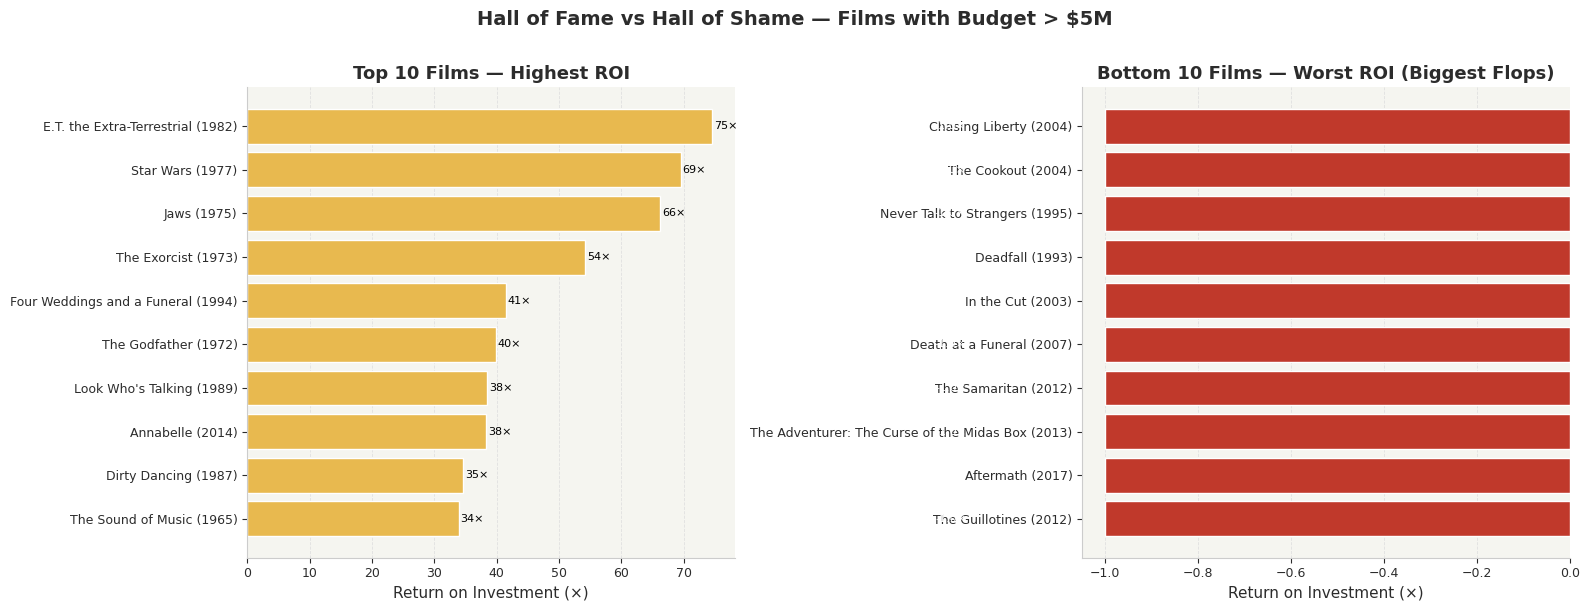

Saved: nb2_hall_of_fame.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Hall of Fame vs Hall of Shame — Films with Budget > $5M",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

# ── Left: Top 10 ROI ────────────────────────────────────────────────
ax   = axes[0]
top  = df_ranked.nlargest(10, "ROI").sort_values("ROI")
labels = [f"{r['title']} ({int(r['release_year'])})" for _, r in top.iterrows()]

ax.barh(labels, top["ROI"], color=GOLD, edgecolor="white")
ax.set_xlabel("Return on Investment (×)")
ax.set_title("Top 10 Films — Highest ROI", color=DARK_TEXT)
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True)
ax.set_axisbelow(True)
for p, val in zip(ax.patches, top["ROI"]):
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height()/2,
            f"{val:.0f}×", va="center", fontsize=8)

# ── Right: Bottom 10 ROI ────────────────────────────────────────────
ax    = axes[1]
flops = df_ranked.nsmallest(10, "ROI").sort_values("ROI", ascending=False)
labels2 = [f"{r['title']} ({int(r['release_year'])})" for _, r in flops.iterrows()]

ax.barh(labels2, flops["ROI"], color=CRIMSON, edgecolor="white")
ax.set_xlabel("Return on Investment (×)")
ax.set_title("Bottom 10 Films — Worst ROI (Biggest Flops)", color=DARK_TEXT)
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True)
ax.set_axisbelow(True)
for p, val in zip(ax.patches, flops["ROI"]):
    ax.text(p.get_width() - 0.3, p.get_y() + p.get_height()/2,
            f"{val:.1f}×", va="center", ha="right", fontsize=8, color="white")

plt.tight_layout()
plt.savefig("nb2_hall_of_fame.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb2_hall_of_fame.png")


## 5 · Summary Statistics Table

In [ ]:
summary = pd.DataFrame({
    "Metric"  : ["Total films analysed",
                 "Median budget",
                 "Median revenue",
                 "Median ROI",
                 "Profitable films (%)",
                 "Most common genre",
                 "Highest median-ROI genre",
                 "Best single-film ROI (budget>$5M)"],
    "Value"   : [
        f"{len(df):,}",
        f"${df['budget'].median()/1e6:.1f}M",
        f"${df['revenue'].median()/1e6:.1f}M",
        f"{df['ROI'].median():.2f}×",
        f"{(df['ROI'] > 0).mean()*100:.1f}%",
        df['primary_genre'].value_counts().index[0],
        genre_stats.iloc[0]['primary_genre'],
        f"{df_ranked['ROI'].max():.0f}×  ({df_ranked.loc[df_ranked['ROI'].idxmax(),'title']})",
    ]
})
print(summary.to_string(index=False))


                           Metric                             Value
             Total films analysed                             5,128
                    Median budget                            $18.0M
                   Median revenue                            $33.5M
                       Median ROI                             1.10×
             Profitable films (%)                             71.1%
                Most common genre                             Drama
         Highest median-ROI genre                       Documentary
Best single-film ROI (budget>$5M) 75×  (E.T. the Extra-Terrestrial)


## ✅ Ready for Notebook 3

In [ ]:
print("All analysis complete.")
print("Charts saved:")
for f in ["nb2_genre_profitability.png","nb2_budget_vs_revenue.png",
          "nb2_monthly_patterns.png","nb2_hall_of_fame.png"]:
    print(f"  ✔  {f}")
print()
print("Proceed to Notebook 3 → Newsletter Visualisations ▶")


All analysis complete.
Charts saved:
  ✔  nb2_genre_profitability.png
  ✔  nb2_budget_vs_revenue.png
  ✔  nb2_monthly_patterns.png
  ✔  nb2_hall_of_fame.png

Proceed to Notebook 3 → Newsletter Visualisations ▶
